# Learning Rate Adaptation: AdaGrad, RMSProp, and Adam

Plain gradient descent has one weakness at its core:

- It uses **one global learning rate** for every parameter, at every step.
- Different parameters often need different step sizes.
- That mismatch is the normal situation in a real network, not an edge
  case.

This notebook builds one small, standard **toy** landscape where that
problem is easy to see, then fixes it one step at a time:

- **AdaGrad**: gives each parameter its own learning rate, shrunk by its
  *accumulated* history of squared gradients.
- **RMSProp**: fixes AdaGrad's main weakness by replacing that
  ever-growing accumulator with an *exponentially weighted moving
  average*.
- **Adam**: adds momentum (an average of the gradients themselves) on top
  of RMSProp's per-parameter scaling.

The notebook ends with all four optimizers trained on a real dataset,
using PyTorch's built-in `torch.optim` implementations.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

torch.manual_seed(0)
np.random.seed(0)

## 1. The Weakness of Plain Gradient Descent

The standard toy landscape for comparing optimizers is the **Rosenbrock
function**:

$$f(x, y) = (1 - x)^2 + 100 (y - x^2)^2$$

Its minimum is at $(1, 1)$, where $f = 0$.

What makes it hard:

- It has a long, narrow, curved valley, not a simple round bowl.
- Inside that valley, the surface is very flat along the valley's length,
  but very steep across it.
- The valley curves. So the "steep" and "flat" directions rotate as you
  move through it.
- A single global learning rate has to stay small enough for the steep
  direction everywhere. That makes it painfully small for the flat
  direction everywhere too.

This exact shape, steep in one direction and flat in another, is why the
Rosenbrock function has been the standard benchmark for optimizer
comparisons for decades.

In [2]:
def rosenbrock(x, y):
    return (1 - x) ** 2 + 100 * (y - x**2) ** 2


gx = np.linspace(-2, 2, 300)
gy = np.linspace(-1, 3.5, 300)
GX, GY = np.meshgrid(gx, gy)
GZ = rosenbrock(GX, GY)

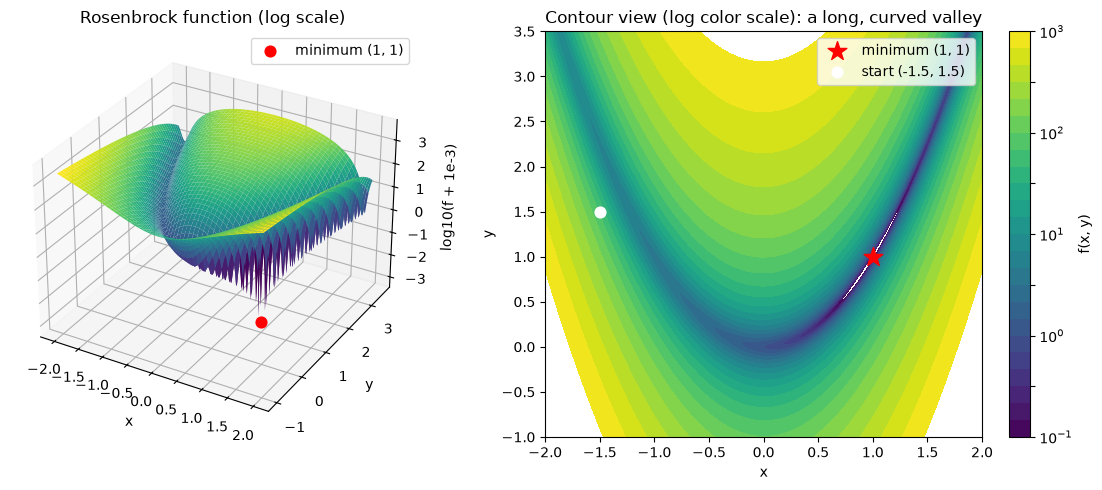

In [3]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(GX, GY, np.log10(GZ + 1e-3), cmap="viridis", linewidth=0, antialiased=True)
ax1.scatter([1], [1], [np.log10(1e-3)], color="red", s=60, label="minimum (1, 1)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("log10(f + 1e-3)")
ax1.set_title("Rosenbrock function (log scale)")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(GX, GY, GZ + 1e-3, levels=np.logspace(-1, 3, 25), norm=LogNorm(), cmap="viridis")
ax2.scatter([1], [1], color="red", marker="*", s=200, label="minimum (1, 1)")
ax2.scatter([-1.5], [1.5], color="white", marker="o", s=60, label="start (-1.5, 1.5)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title("Contour view (log color scale): a long, curved valley")
ax2.legend()
fig.colorbar(cs, ax=ax2, label="f(x, y)")

plt.tight_layout()
plt.show()

### Plain gradient descent: safe but slow

Start at $(-1.5, 1.5)$ and run plain gradient descent with a small,
stable learning rate.

In [4]:
def gd(x0, y0, lr, steps):
    xy = torch.tensor([x0, y0], dtype=torch.float64, requires_grad=True)
    path = [xy.detach().numpy().copy()]
    for _ in range(steps):
        loss = rosenbrock(xy[0], xy[1])
        loss.backward()
        with torch.no_grad():
            xy -= lr * xy.grad
        xy.grad.zero_()
        path.append(xy.detach().numpy().copy())
        if not torch.isfinite(xy).all():
            break
    return np.array(path)

In [5]:
x0, y0 = -1.5, 1.5
gd_safe = gd(x0, y0, lr=0.002, steps=2000)

xf, yf = gd_safe[-1]
print(f"after 2000 steps: (x, y) = ({xf:.4f}, {yf:.4f})   f = {rosenbrock(torch.tensor(xf), torch.tensor(yf)).item():.4e}")
print("still nowhere near the minimum (1, 1), despite 2000 iterations.")

after 2000 steps: (x, y) = (0.9064, 0.8211)   f = 8.7803e-03
still nowhere near the minimum (1, 1), despite 2000 iterations.


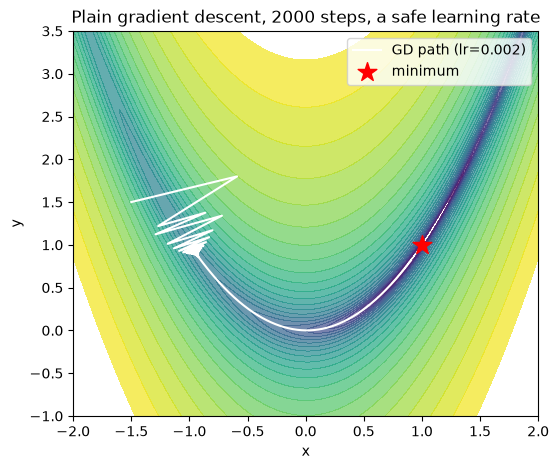

In [6]:
plt.figure(figsize=(6, 5))
cs = plt.contourf(GX, GY, GZ + 1e-3, levels=np.logspace(-1, 3, 25), norm=LogNorm(), cmap="viridis", alpha=0.7)
plt.plot(gd_safe[:, 0], gd_safe[:, 1], color="white", linewidth=1.5, label="GD path (lr=0.002)")
plt.scatter([1], [1], color="red", marker="*", s=200, label="minimum")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Plain gradient descent, 2000 steps, a safe learning rate")
plt.legend()
plt.show()

### Plain gradient descent: a little faster, and it explodes

Only the learning rate changes: from `0.002` to `0.005`, roughly double.
Nothing else changes.

In [7]:
gd_unsafe = gd(x0, y0, lr=0.005, steps=15)

print("x at each step:")
for i, (x, y) in enumerate(gd_unsafe):
    print(f"  step {i}: x = {x:.6g}")

x at each step:
  step 0: x = -1.5
  step 1: x = 0.775
  step 2: x = 3.33378
  step 3: x = -66.7888
  step 4: x = 594305
  step 5: x = -4.19814e+17
  step 6: x = 1.47979e+53
  step 7: x = -6.48087e+159
  step 8: x = inf


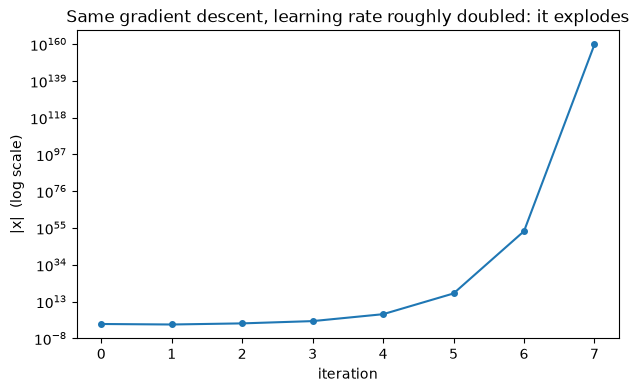

In [8]:
plt.figure(figsize=(7, 4))
plt.semilogy(np.abs(gd_unsafe[:, 0]), marker="o", markersize=4)
plt.xlabel("iteration")
plt.ylabel("|x|  (log scale)")
plt.title("Same gradient descent, learning rate roughly doubled: it explodes")
plt.show()

- At `lr=0.002`, gradient descent is stable, but 2000 steps are not
  enough to get anywhere close to the minimum.
- At `lr=0.005`, barely more aggressive, it diverges to `inf` within
  about 8 steps.
- The steep and flat directions of this valley need very different step
  sizes.
- Plain gradient descent can only offer one step size for everything, so
  no single learning rate here is both fast and safe.

This is exactly the gap that adaptive per-parameter learning rates are
designed to close.

## 2. AdaGrad: Accumulating Historical Gradients

AdaGrad keeps a running sum of squared gradients for **each parameter
separately**. It then divides that parameter's learning rate by the
square root of that sum:

$$G_t = G_{t-1} + g_t^2 \qquad \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{G_t} + \epsilon} \, g_t$$

- A parameter whose gradients have historically been large (the steep
  direction) gets its step size shrunk a lot.
- A parameter whose gradients have historically been small (the flat
  direction) gets its step size shrunk only a little.
- One global $\eta$ is still set by hand, but $G_t$ does the rest of the
  work automatically, per parameter.

In [9]:
def adagrad(x0, y0, lr, steps, eps=1e-8):
    xy = torch.tensor([x0, y0], dtype=torch.float64, requires_grad=True)
    G = torch.zeros(2, dtype=torch.float64)
    path = [xy.detach().numpy().copy()]
    for _ in range(steps):
        loss = rosenbrock(xy[0], xy[1])
        loss.backward()
        with torch.no_grad():
            G += xy.grad ** 2
            xy -= lr * xy.grad / (G.sqrt() + eps)
        xy.grad.zero_()
        path.append(xy.detach().numpy().copy())
    return np.array(path)


ada = adagrad(x0, y0, lr=2.0, steps=2000)

xf, yf = ada[-1]
print(f"AdaGrad after 2000 steps: (x, y) = ({xf:.4f}, {yf:.4f})   f = {rosenbrock(torch.tensor(xf), torch.tensor(yf)).item():.4e}")
print(f"plain GD  after 2000 steps: f = {rosenbrock(*torch.tensor(gd_safe[-1])).item():.4e}")

AdaGrad after 2000 steps: (x, y) = (0.9637, 0.9286)   f = 1.3206e-03
plain GD  after 2000 steps: f = 8.7803e-03


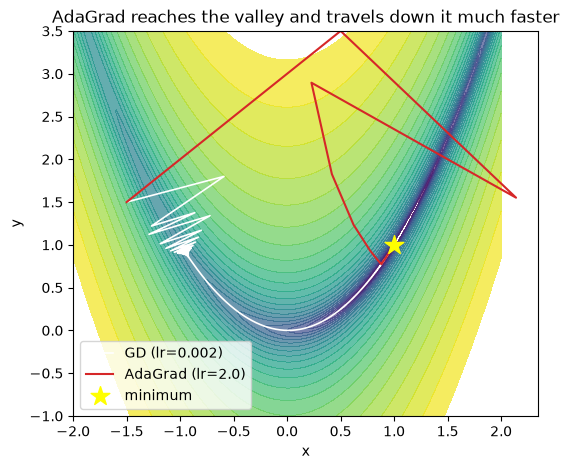

In [10]:
plt.figure(figsize=(6, 5))
cs = plt.contourf(GX, GY, GZ + 1e-3, levels=np.logspace(-1, 3, 25), norm=LogNorm(), cmap="viridis", alpha=0.7)
plt.plot(gd_safe[:, 0], gd_safe[:, 1], color="white", linewidth=1.2, label="GD (lr=0.002)")
plt.plot(ada[:, 0], ada[:, 1], color="tab:red", linewidth=1.5, label="AdaGrad (lr=2.0)")
plt.scatter([1], [1], color="yellow", marker="*", s=200, zorder=5, label="minimum")
plt.xlabel("x"); plt.ylabel("y")
plt.title("AdaGrad reaches the valley and travels down it much faster")
plt.legend()
plt.show()

AdaGrad also tolerates a much wider range of learning rates than plain
gradient descent did.

- Plain GD was only stable below `lr~0.002`.
- AdaGrad stays well behaved from `lr=1` all the way to `lr=2`.
- Even at `lr=100`, it only drifts. It does not explode to `inf`, because
  the accumulated $G_t$ grows right along with the gradient and keeps the
  update in check.

In [11]:
print("AdaGrad final loss across a wide range of learning rates:")
for lr in [1, 2, 5, 10, 50, 100]:
    path = adagrad(x0, y0, lr=lr, steps=2000)
    xf, yf = path[-1]
    print(f"  lr={lr:<5} f = {rosenbrock(torch.tensor(xf), torch.tensor(yf)).item():.4e}")

AdaGrad final loss across a wide range of learning rates:
  lr=1     f = 2.6558e-02
  lr=2     f = 1.3206e-03
  lr=5     f = 2.5909e-01
  lr=10    f = 1.9949e+01
  lr=50    f = 4.7535e+01
  lr=100   f = 6.4358e+01


### AdaGrad's weakness: the accumulator only ever grows

- $G_t$ is a running **sum**, so it never shrinks.
- As training goes on, the effective learning rate $\eta / \sqrt{G_t}$
  keeps shrinking too, forever. Even in regions where the gradient has
  been small and steady for a long time.
- On a long training run, this can shrink the effective learning rate to
  essentially zero long before the model is done learning.

To see the mechanism on its own, set the Rosenbrock function aside for a
moment. Just feed AdaGrad's update rule the same gradient magnitude,
$g=1$, over and over.

In [12]:
def effective_step_adagrad(g_seq, lr=1.0, eps=1e-8):
    G = 0.0
    steps = []
    for g in g_seq:
        G += g**2
        steps.append(lr / (np.sqrt(G) + eps))
    return np.array(steps)


t = np.arange(1, 2001)
g_seq = np.ones_like(t, dtype=float)  # a constant-magnitude gradient, every step
adagrad_step = effective_step_adagrad(g_seq)

for n in [10, 100, 1000, 2000]:
    print(f"after {n:4d} steps of a constant-size gradient, AdaGrad's effective step size = {adagrad_step[n-1]:.4g}")

after   10 steps of a constant-size gradient, AdaGrad's effective step size = 0.3162
after  100 steps of a constant-size gradient, AdaGrad's effective step size = 0.1
after 1000 steps of a constant-size gradient, AdaGrad's effective step size = 0.03162
after 2000 steps of a constant-size gradient, AdaGrad's effective step size = 0.02236


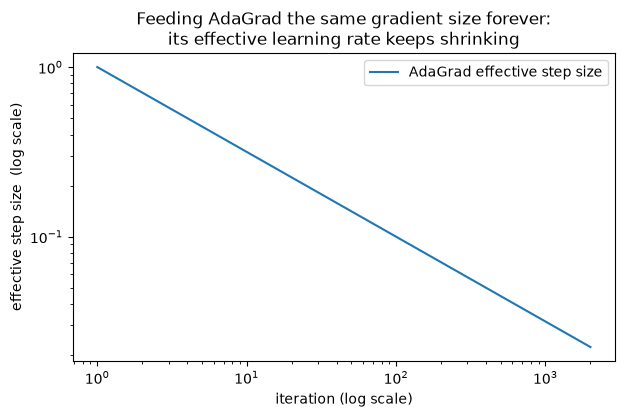

In [13]:
plt.figure(figsize=(7, 4))
plt.loglog(t, adagrad_step, label="AdaGrad effective step size")
plt.xlabel("iteration (log scale)")
plt.ylabel("effective step size  (log scale)")
plt.title("Feeding AdaGrad the same gradient size forever:\nits effective learning rate keeps shrinking")
plt.legend()
plt.show()

- Even though the gradient magnitude never changed, AdaGrad's effective
  step size keeps falling, roughly as $1/\sqrt{t}$.
- In a long training run, this means learning can grind to a halt long
  before the model has actually converged, simply because $G_t$ has been
  accumulating for a long time.

## 3. RMSProp: Exponentially Weighted Moving Average of Gradients

RMSProp keeps the same idea as AdaGrad: divide each parameter's step by
the size of its recent squared gradients. The difference is what it
divides by. RMSProp replaces the ever-growing **sum** with an
exponentially weighted **moving average**:

$$S_t = \beta S_{t-1} + (1 - \beta) g_t^2 \qquad \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{S_t} + \epsilon} \, g_t$$

- Old gradients are gradually forgotten, controlled by $\beta$ (typically
  around 0.9-0.99), instead of being remembered forever.
- $S_t$ settles into a value that tracks the *recent* gradient magnitude,
  rather than growing without bound.
- The effective learning rate can go back up again if gradients shrink.
  AdaGrad could never do that.

In [14]:
def rmsprop(x0, y0, lr, steps, beta=0.99, eps=1e-8):
    xy = torch.tensor([x0, y0], dtype=torch.float64, requires_grad=True)
    S = torch.zeros(2, dtype=torch.float64)
    path = [xy.detach().numpy().copy()]
    for _ in range(steps):
        loss = rosenbrock(xy[0], xy[1])
        loss.backward()
        with torch.no_grad():
            S.mul_(beta).add_(xy.grad ** 2, alpha=1 - beta)
            xy -= lr * xy.grad / (S.sqrt() + eps)
        xy.grad.zero_()
        path.append(xy.detach().numpy().copy())
    return np.array(path)


rms = rmsprop(x0, y0, lr=0.003, steps=2000)

xf, yf = rms[-1]
print(f"RMSProp after 2000 steps: (x, y) = ({xf:.4f}, {yf:.4f})   f = {rosenbrock(torch.tensor(xf), torch.tensor(yf)).item():.4e}")

RMSProp after 2000 steps: (x, y) = (0.8770, 0.7735)   f = 1.7017e-02


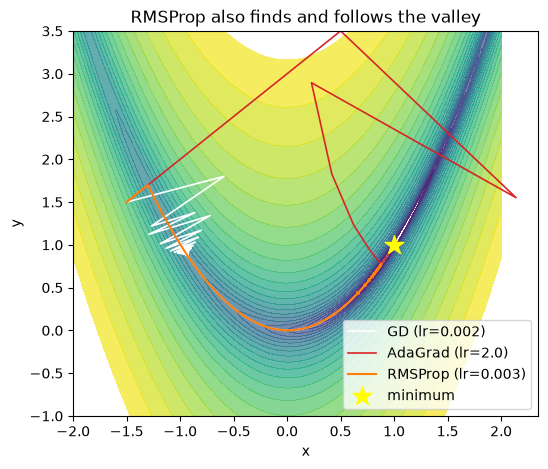

In [15]:
plt.figure(figsize=(6, 5))
cs = plt.contourf(GX, GY, GZ + 1e-3, levels=np.logspace(-1, 3, 25), norm=LogNorm(), cmap="viridis", alpha=0.7)
plt.plot(gd_safe[:, 0], gd_safe[:, 1], color="white", linewidth=1.2, label="GD (lr=0.002)")
plt.plot(ada[:, 0], ada[:, 1], color="tab:red", linewidth=1.2, label="AdaGrad (lr=2.0)")
plt.plot(rms[:, 0], rms[:, 1], color="tab:orange", linewidth=1.5, label="RMSProp (lr=0.003)")
plt.scatter([1], [1], color="yellow", marker="*", s=200, zorder=5, label="minimum")
plt.xlabel("x"); plt.ylabel("y")
plt.title("RMSProp also finds and follows the valley")
plt.legend()
plt.show()

Feed RMSProp the same constant-size gradient sequence as before, and
compare its effective step size against AdaGrad's on the same axes.

In [16]:
def effective_step_rmsprop(g_seq, lr=1.0, beta=0.99, eps=1e-8):
    S = 0.0
    steps = []
    for g in g_seq:
        S = beta * S + (1 - beta) * g**2
        steps.append(lr / (np.sqrt(S) + eps))
    return np.array(steps)


rmsprop_step = effective_step_rmsprop(g_seq)

print(f"AdaGrad  effective step after 2000 identical-size gradients: {adagrad_step[-1]:.4g}")
print(f"RMSProp  effective step after 2000 identical-size gradients: {rmsprop_step[-1]:.4g}")

AdaGrad  effective step after 2000 identical-size gradients: 0.02236
RMSProp  effective step after 2000 identical-size gradients: 1


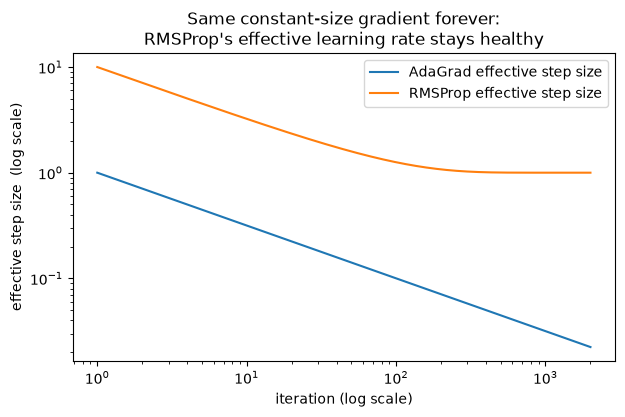

In [17]:
plt.figure(figsize=(7, 4))
plt.loglog(t, adagrad_step, label="AdaGrad effective step size")
plt.loglog(t, rmsprop_step, label="RMSProp effective step size")
plt.xlabel("iteration (log scale)")
plt.ylabel("effective step size  (log scale)")
plt.title("Same constant-size gradient forever:\nRMSProp's effective learning rate stays healthy")
plt.legend()
plt.show()

- AdaGrad's effective step keeps decaying toward zero, no matter how long
  training runs.
- RMSProp's effective step converges to a steady value and stays there,
  as long as the gradient magnitude stays roughly steady.
- That is precisely why RMSProp remains usable on long training runs
  where AdaGrad tends to stall out.

## 4. Adam: Combining Momentum and RMSProp

Adam keeps RMSProp's per-parameter second-moment scaling. It adds a
**first moment** on top: an exponentially weighted moving average of the
gradients themselves, which acts as momentum.

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

Both moving averages start at 0, which biases their early values toward
0. Adam corrects for that bias before using them:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \qquad \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \, \hat{m}_t$$

- $m_t$ smooths out noisy or oscillating gradients before they are
  applied.
- $v_t$ is exactly RMSProp's per-parameter scaling.
- Adam is, quite literally, momentum applied on top of RMSProp.

In [18]:
def adam(x0, y0, lr, steps, beta1=0.9, beta2=0.999, eps=1e-8):
    xy = torch.tensor([x0, y0], dtype=torch.float64, requires_grad=True)
    m = torch.zeros(2, dtype=torch.float64)
    v = torch.zeros(2, dtype=torch.float64)
    path = [xy.detach().numpy().copy()]
    for step in range(1, steps + 1):
        loss = rosenbrock(xy[0], xy[1])
        loss.backward()
        with torch.no_grad():
            m.mul_(beta1).add_(xy.grad, alpha=1 - beta1)
            v.mul_(beta2).add_(xy.grad ** 2, alpha=1 - beta2)
            m_hat = m / (1 - beta1 ** step)
            v_hat = v / (1 - beta2 ** step)
            xy -= lr * m_hat / (v_hat.sqrt() + eps)
        xy.grad.zero_()
        path.append(xy.detach().numpy().copy())
    return np.array(path)


adm = adam(x0, y0, lr=0.1, steps=2000)

xf, yf = adm[-1]
print(f"Adam after 2000 steps: (x, y) = ({xf:.5f}, {yf:.5f})   f = {rosenbrock(torch.tensor(xf), torch.tensor(yf)).item():.4e}")
print("essentially exact: Adam lands almost exactly on the minimum (1, 1).")

Adam after 2000 steps: (x, y) = (0.99995, 0.99990)   f = 2.2992e-09
essentially exact: Adam lands almost exactly on the minimum (1, 1).


### All four optimizers, side by side

Same starting point, same 2000-step budget, four different update rules.

In [19]:
def loss_curve(path):
    return np.array([rosenbrock(torch.tensor(p[0]), torch.tensor(p[1])).item() for p in path])


gd_curve = loss_curve(gd_safe)
ada_curve = loss_curve(ada)
rms_curve = loss_curve(rms)
adm_curve = loss_curve(adm)

print("final f(x, y) after 2000 steps, lowest is best:")
for name, curve in [("GD", gd_curve), ("AdaGrad", ada_curve), ("RMSProp", rms_curve), ("Adam", adm_curve)]:
    print(f"  {name:8s}: f = {curve[-1]:.4e}")

final f(x, y) after 2000 steps, lowest is best:
  GD      : f = 8.7803e-03
  AdaGrad : f = 1.3206e-03
  RMSProp : f = 1.7017e-02
  Adam    : f = 2.2992e-09


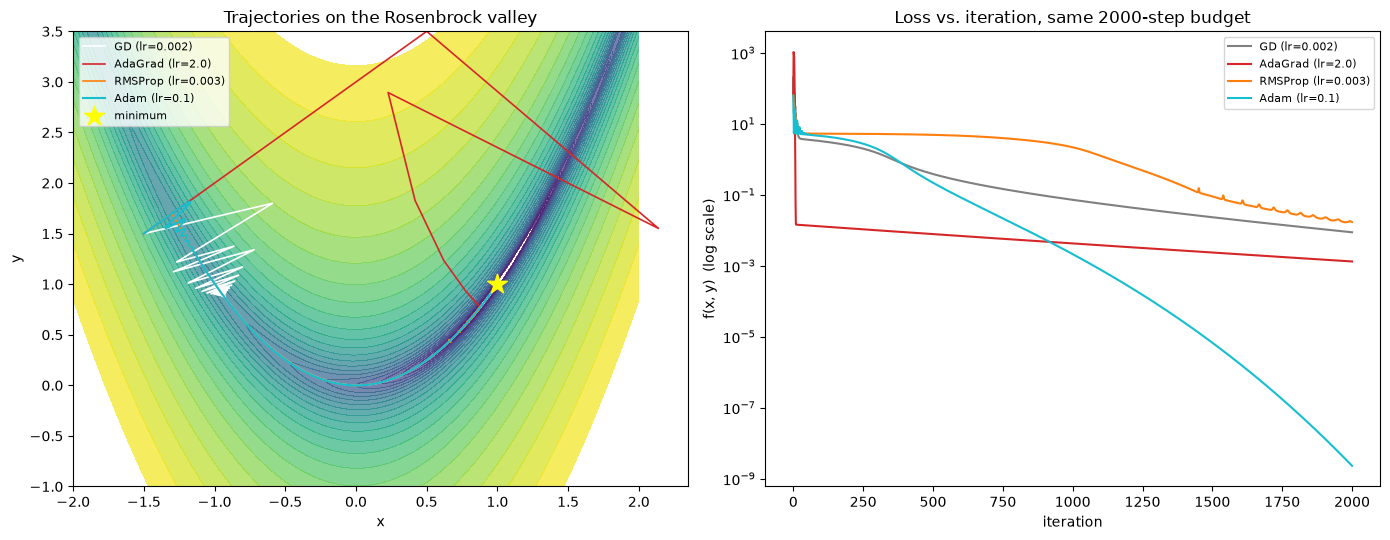

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].contourf(GX, GY, GZ + 1e-3, levels=np.logspace(-1, 3, 25), norm=LogNorm(), cmap="viridis", alpha=0.7)
axes[0].plot(gd_safe[:, 0], gd_safe[:, 1], color="white", linewidth=1.2, label="GD (lr=0.002)")
axes[0].plot(ada[:, 0], ada[:, 1], color="tab:red", linewidth=1.2, label="AdaGrad (lr=2.0)")
axes[0].plot(rms[:, 0], rms[:, 1], color="tab:orange", linewidth=1.2, label="RMSProp (lr=0.003)")
axes[0].plot(adm[:, 0], adm[:, 1], color="tab:cyan", linewidth=1.5, label="Adam (lr=0.1)")
axes[0].scatter([1], [1], color="yellow", marker="*", s=220, zorder=5, label="minimum")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("Trajectories on the Rosenbrock valley")
axes[0].legend(fontsize=8)

axes[1].semilogy(gd_curve, color="gray", label="GD (lr=0.002)")
axes[1].semilogy(ada_curve, color="tab:red", label="AdaGrad (lr=2.0)")
axes[1].semilogy(rms_curve, color="tab:orange", label="RMSProp (lr=0.003)")
axes[1].semilogy(adm_curve, color="tab:cyan", label="Adam (lr=0.1)")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("f(x, y)  (log scale)")
axes[1].set_title("Loss vs. iteration, same 2000-step budget")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

- Plain gradient descent, restricted to a safe learning rate, is still
  far from the minimum after 2000 steps.
- AdaGrad and RMSProp both reach the valley and travel a long way down
  it.
- Both land much closer to the minimum than plain GD, but still fall
  short of exact convergence within this budget.
- Adam, combining momentum with RMSProp's scaling, is the only one of
  the four that reaches the minimum almost exactly within the same 2000
  steps.

### The extra ingredient: momentum smooths noisy gradients

- RMSProp's second moment, $v_t$, is built from squared gradients. It
  only ever measures the *size* of recent gradients, not their
  *direction*.
- Adam's first moment, $m_t$, averages the gradients themselves. It
  smooths out noise in the direction too.

To see that difference on its own, add random noise to every gradient,
as a stand-in for the noise a real mini-batch gradient carries. Then
watch RMSProp and Adam handle it.

In [21]:
def true_grad_1d(w):
    return 2 * w  # gradient of w^2


def run_noisy(w0, lr, steps, method, noise_seed=0, sigma=2.0,
              beta=0.99, beta1=0.9, beta2=0.999, eps=1e-8):
    rng = np.random.default_rng(noise_seed)
    w = w0
    S = 0.0
    m = 0.0
    path = [w]
    for step in range(1, steps + 1):
        g = true_grad_1d(w) + rng.normal(0, sigma)
        if method == "rmsprop":
            S = beta * S + (1 - beta) * g**2
            w -= lr * g / (np.sqrt(S) + eps)
        elif method == "adam":
            m = beta1 * m + (1 - beta1) * g
            S = beta2 * S + (1 - beta2) * g**2
            m_hat = m / (1 - beta1**step)
            S_hat = S / (1 - beta2**step)
            w -= lr * m_hat / (np.sqrt(S_hat) + eps)
        path.append(w)
    return np.array(path)


w0, lr, steps = 2.0, 0.1, 150
rmsprop_noisy = run_noisy(w0, lr, steps, "rmsprop")
adam_noisy = run_noisy(w0, lr, steps, "adam")

print(f"RMSProp: std of w over the last 50 steps = {np.std(rmsprop_noisy[-50:]):.4f}")
print(f"Adam:    std of w over the last 50 steps = {np.std(adam_noisy[-50:]):.4f}")

RMSProp: std of w over the last 50 steps = 0.2117
Adam:    std of w over the last 50 steps = 0.0977


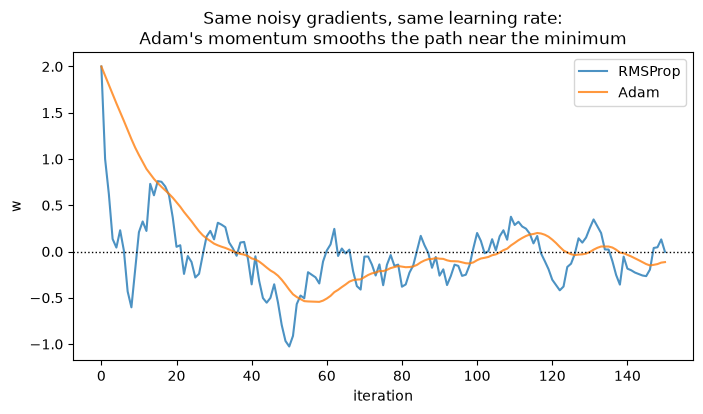

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(rmsprop_noisy, label="RMSProp", alpha=0.8)
plt.plot(adam_noisy, label="Adam", alpha=0.8)
plt.axhline(0, color="black", linewidth=1, linestyle=":")
plt.xlabel("iteration"); plt.ylabel("w")
plt.title("Same noisy gradients, same learning rate:\nAdam's momentum smooths the path near the minimum")
plt.legend()
plt.show()

- Both optimizers settle near $w=0$, the true minimum.
- RMSProp's path is visibly jumpier once it gets close. Each individual
  noisy gradient still pushes it around, since only the *step size* is
  controlled, not the *direction*.
- Adam's momentum term averages several recent noisy gradients together
  before taking a step, so its path settles down more smoothly.

## Takeaways from the toy examples

- **Plain gradient descent** uses one global learning rate for every
  parameter. On a landscape where different directions need very
  different step sizes, that one learning rate is forced into an
  impossible trade-off: stable, or fast enough, never both.
- **AdaGrad** gives each parameter its own learning rate, scaled down by
  that parameter's accumulated squared gradients. It handles the scale
  mismatch well, but its accumulator only grows, so the effective
  learning rate shrinks toward zero over a long run.
- **RMSProp** replaces AdaGrad's ever-growing sum with an exponentially
  weighted moving average. The effective learning rate tracks recent
  gradient magnitudes instead of decaying forever.
- **Adam** adds a momentum term, a moving average of the gradients
  themselves, on top of RMSProp's per-parameter scaling. Momentum is
  what smooths out noisy, oscillating gradients, which the scaling term
  alone cannot do.
- On the same 2000-step budget, on the same landscape, Adam was the only
  optimizer to actually reach the minimum.

## 5. A Real Example: Optimizers on the Digits Dataset

Now the same four update rules, via PyTorch's built-in `torch.optim`
implementations, trained on a real (if small) dataset.

- Dataset: `sklearn`'s digits dataset.
- 1797 images, 8x8 pixels, grayscale.
- 10 classes (digits 0-9).

To make the comparison direct:

- Every optimizer trains the exact same small network.
- Every optimizer starts from the exact same initial weights.
- Every optimizer uses the exact same learning rate.
- Only the update rule changes.

In [23]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data.astype(np.float32) / 16.0  # pixel values are 0-16
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(X_test)
y_test = torch.from_numpy(y_test)

print(f"train: {X_train.shape}, test: {X_test.shape}, classes: {len(set(y.tolist()))}")

train: torch.Size([1437, 64]), test: torch.Size([360, 64]), classes: 10


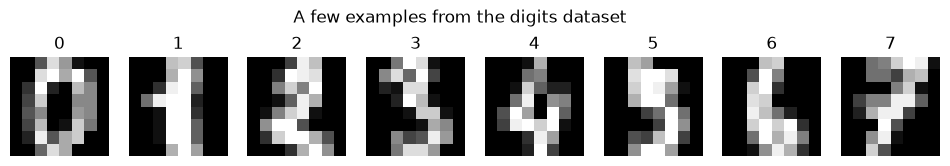

In [24]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(str(digits.target[i]))
    ax.axis("off")
plt.suptitle("A few examples from the digits dataset")
plt.show()

In [ ]:
class DigitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(0)
initial_state = DigitMLP().state_dict()  # every optimizer starts from this exact state

In [ ]:
def make_model():
    model = DigitMLP()
    model.load_state_dict(initial_state)
    return model


def train_digits(optimizer_name, lr, epochs=40, batch_size=32, seed=0):
    torch.manual_seed(seed)
    model = make_model()
    optimizer_cls = {
        "SGD": torch.optim.SGD,
        "AdaGrad": torch.optim.Adagrad,
        "RMSProp": torch.optim.RMSprop,
        "Adam": torch.optim.Adam,
    }[optimizer_name]
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    n = X_train.shape[0]
    epoch_losses = []
    for _ in range(epochs):
        perm = torch.randperm(n)
        running_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(idx)
        epoch_losses.append(running_loss / n)

    model.eval()
    with torch.no_grad():
        test_acc = (model(X_test).argmax(1) == y_test).float().mean().item()
    return epoch_losses, test_acc

In [26]:
lr = 0.001  # the same, deliberately conservative, learning rate for all four
results = {}
for name in ["SGD", "AdaGrad", "RMSProp", "Adam"]:
    losses, test_acc = train_digits(name, lr=lr, epochs=40)
    results[name] = (losses, test_acc)
    print(f"{name:8s}  final train loss = {losses[-1]:.4f}   test accuracy = {test_acc:.4f}")

SGD       final train loss = 2.1443   test accuracy = 0.6111
AdaGrad   final train loss = 1.0505   test accuracy = 0.8750
RMSProp   final train loss = 0.0277   test accuracy = 0.9778
Adam      final train loss = 0.0368   test accuracy = 0.9722


In [27]:
names = list(results.keys())
test_accs = [results[n][1] for n in names]

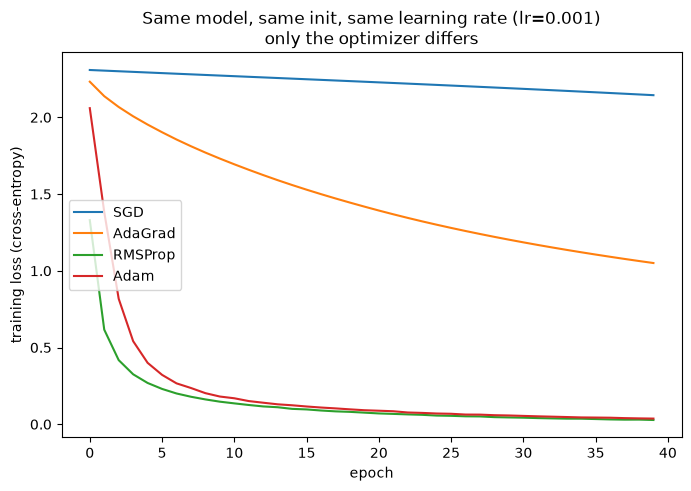

In [28]:
plt.figure(figsize=(8, 5))
for name, (losses, _) in results.items():
    plt.plot(losses, label=name)
plt.xlabel("epoch")
plt.ylabel("training loss (cross-entropy)")
plt.title(f"Same model, same init, same learning rate (lr={lr})\nonly the optimizer differs")
plt.legend()
plt.show()

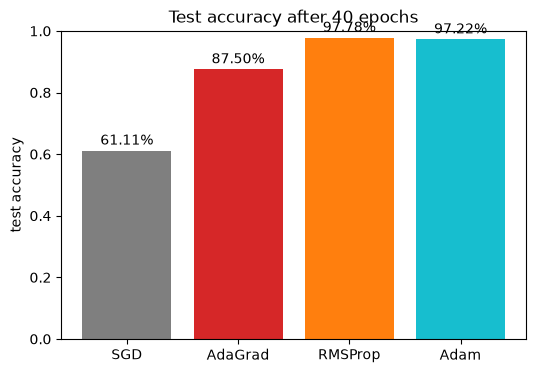

In [29]:
plt.figure(figsize=(6, 4))
plt.bar(names, test_accs, color=["tab:gray", "tab:red", "tab:orange", "tab:cyan"])
plt.ylabel("test accuracy")
plt.ylim(0, 1)
plt.title("Test accuracy after 40 epochs")
for i, acc in enumerate(test_accs):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha="center")
plt.show()

- At this learning rate, plain SGD is still barely learning after 40
  epochs. It is not broken, only slow: the same "safe but slow" behavior
  seen on the Rosenbrock valley, now on real data.
- AdaGrad makes real progress but is also still catching up after 40
  epochs, again consistent with its toy behavior.
- RMSProp and Adam both adapt their effective per-parameter learning rate
  automatically. Both reach a good solution within the same 40 epochs,
  at the exact same nominal learning rate that left plain SGD stuck.
- This mirrors, on real data, exactly what the toy Rosenbrock experiments
  predicted: a fixed global learning rate is a much bigger handicap for
  plain SGD than it is for the adaptive methods.